# Associated File Paths

In [2]:
input_file_path = '/Users/john_1john_1/Documents/Legant_Lab/h2b_tracking_csv_for_john240416/ds210418_ctrl_rep1_cell1_240416.csv'
output_file_path = '/Users/john_1john_1/Documents/Legant_Lab/Filtered Data/testing11111.csv'
selected_dim = 2
selected_max_fs = 3

# Import Required Libraries

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math as math
import JGparticle

In [5]:
import numpy as np


# Import Functions

In [7]:
from JGparticle.Trajectory_Span import calculate_trajectory_span
from JGparticle.Max_Uncertainty import maximum_uncertainty
from JGparticle.Max_Jump_Distance import max_jump_distance
from JGparticle.DisplacementCalculation_3col import calculate_displacement_3_column
from JGparticle.Convert_Legant_CSV import legant_compatible_TARDIS
from JGparticle.Graphical_Comparison import histogram_plotting
from JGparticle.Plot_ECDF import compare_ecdf
from JGparticle.Compare_Displacements import probability_densities

# Required TARDIS Parameters

In [9]:
def gen_tar_param(file_path,max_dt,dim):
    print(f'Maximum Jump Distance: {np.round(max_jump_distance(max_dt,dim,file_path),decimals=2)} μm')
    print(f'Max ∆T: {selected_max_fs}')
    print(f'Frame time: 20 (ms)')
    print(f'Longest Track Length: {int(calculate_trajectory_span(file_path))}')
    print(f'Localization Uncertainty: {np.round(maximum_uncertainty(file_path,dim),decimals=2)} nm')

In [10]:
gen_tar_param(input_file_path,selected_max_fs,selected_dim)

Maximum Jump Distance: 0.89 μm
Max ∆T: 3
Frame time: 20 (ms)
Longest Track Length: 196
Localization Uncertainty: 50.0 nm


# Convert Legant Data To TARDIS Data 

In [12]:
legant_compatible_TARDIS(input_file_path,output_file_path,selected_dim)

Done. The data was saved to /Users/john_1john_1/Documents/Legant_Lab/Filtered Data/testing11111.csv


# Import TARDIS Jump Distances

Utilize MATLAB ExpPdata.m script to export TARDIS Jump Distances

In [15]:
TARDIS_JDs_path = '/Users/john_1john_1/Documents/Legant_Lab/Filtered Data/testingTARDIS1.csv'

In [16]:
def convert_tardisD_nm(s_path):
    df = pd.read_csv(s_path)
    selected_df = df[['dT = 1','dT = 2','dT = 3']]
    return selected_df.multiply(10**9)

In [17]:
JDs_TARDIS = convert_tardisD_nm(TARDIS_JDs_path)
print(JDs_TARDIS)

            dT = 1      dT = 2      dT = 3
0       161.838208   96.161823   64.000278
1        67.486825   53.503645   31.990518
2       145.550274  154.353459   28.706294
3        17.567318   22.953094  140.775335
4        63.775606   53.269226  154.875648
...            ...         ...         ...
199149         NaN         NaN         NaN
199150         NaN         NaN         NaN
199151         NaN         NaN         NaN
199152         NaN         NaN         NaN
199153         NaN         NaN         NaN

[199154 rows x 3 columns]


# Calculate Jump Distances (Python)

In [19]:
JDs_python = calculate_displacement_3_column(selected_max_fs,selected_dim,input_file_path)
print(JDs_python)

           dT = 1      dT = 2     dT = 3
0       87.043520   54.088627  91.571811
1       76.820947   21.137758  65.032230
2       92.659538  116.484861        NaN
3       76.780152         NaN        NaN
4             NaN         NaN  23.083654
...           ...         ...        ...
89792   19.977048         NaN        NaN
89793   52.756904         NaN        NaN
89794  174.760564         NaN        NaN
89795  129.728242         NaN        NaN
89796   51.413930         NaN        NaN

[89797 rows x 3 columns]


# Statistical Analysis

## Histograms

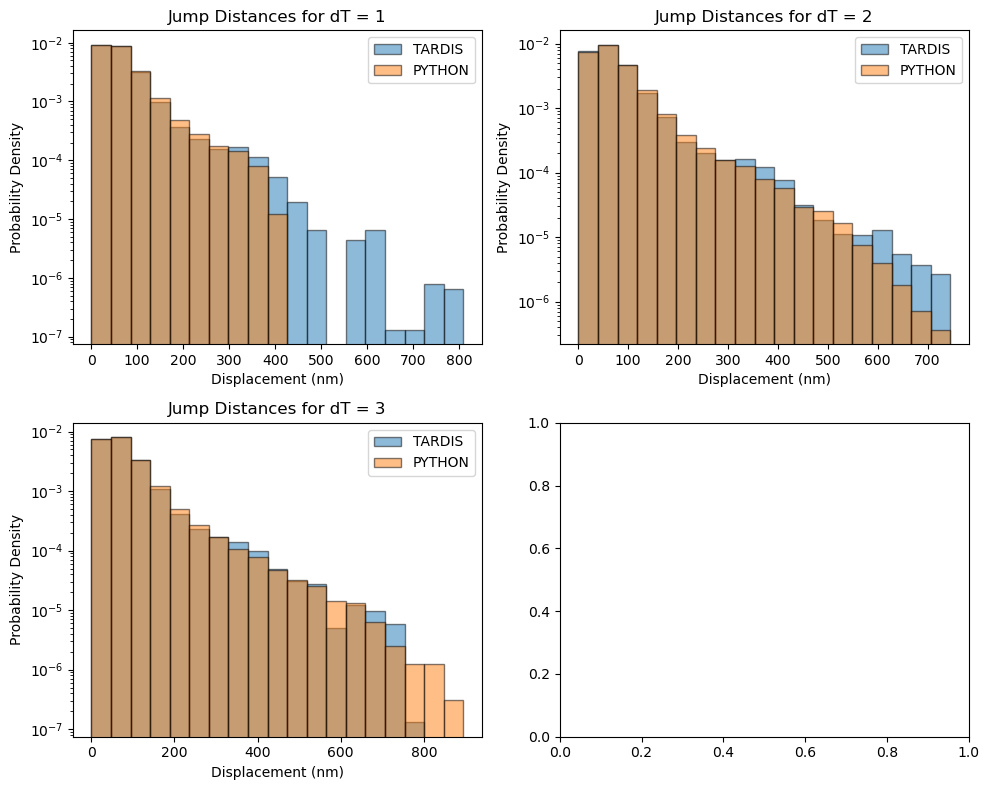

In [22]:
histogram_plotting(JDs_TARDIS,JDs_python,selected_max_fs)

# Compare Displacements

/Users/john_1john_1/Dropbox/Legant Lab/JGparticle/Compare_Displacements.py:24: RuntimeWarning: invalid value encountered in divide
  ratio = np.nan_to_num(python_hist / tardis_hist, nan=0.0, posinf=0.0, neginf=0.0)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


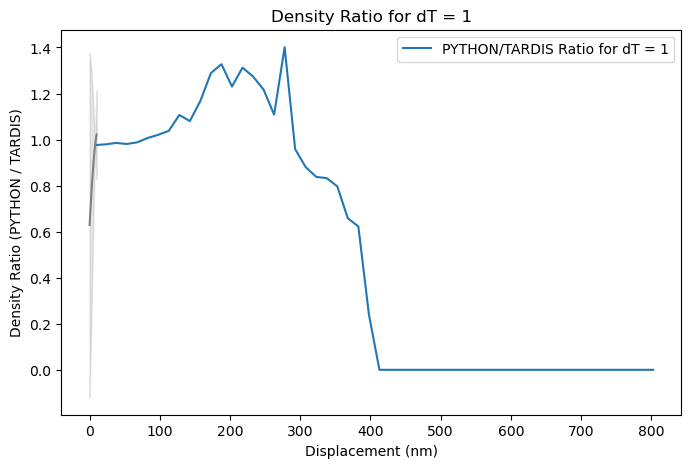

/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


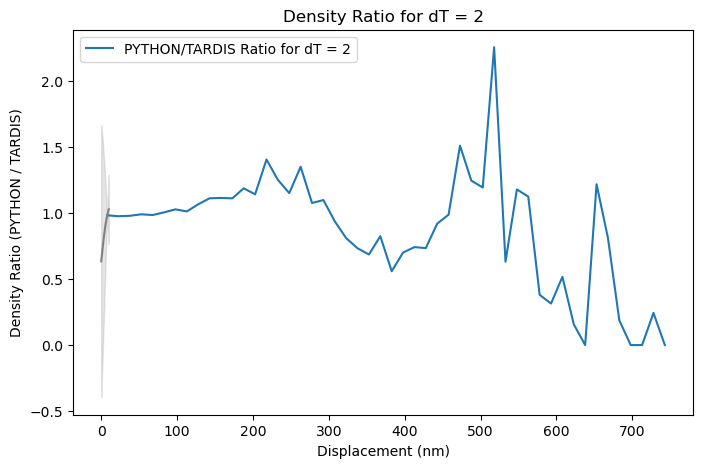

/Users/john_1john_1/Dropbox/Legant Lab/JGparticle/Compare_Displacements.py:24: RuntimeWarning: divide by zero encountered in divide
  ratio = np.nan_to_num(python_hist / tardis_hist, nan=0.0, posinf=0.0, neginf=0.0)
/Users/john_1john_1/Dropbox/Legant Lab/JGparticle/Compare_Displacements.py:24: RuntimeWarning: invalid value encountered in divide
  ratio = np.nan_to_num(python_hist / tardis_hist, nan=0.0, posinf=0.0, neginf=0.0)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


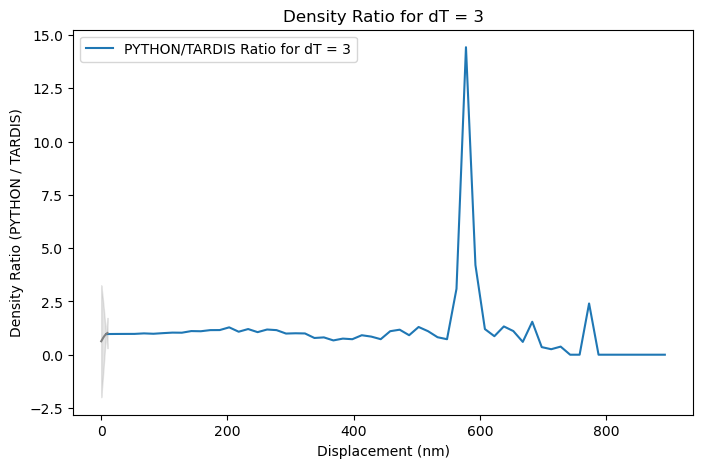

({'dT = 1': {'bins': array([3.26484576e-01, 1.53264846e+01, 3.03264846e+01, 4.53264846e+01,
          6.03264846e+01, 7.53264846e+01, 9.03264846e+01, 1.05326485e+02,
          1.20326485e+02, 1.35326485e+02, 1.50326485e+02, 1.65326485e+02,
          1.80326485e+02, 1.95326485e+02, 2.10326485e+02, 2.25326485e+02,
          2.40326485e+02, 2.55326485e+02, 2.70326485e+02, 2.85326485e+02,
          3.00326485e+02, 3.15326485e+02, 3.30326485e+02, 3.45326485e+02,
          3.60326485e+02, 3.75326485e+02, 3.90326485e+02, 4.05326485e+02,
          4.20326485e+02, 4.35326485e+02, 4.50326485e+02, 4.65326485e+02,
          4.80326485e+02, 4.95326485e+02, 5.10326485e+02, 5.25326485e+02,
          5.40326485e+02, 5.55326485e+02, 5.70326485e+02, 5.85326485e+02,
          6.00326485e+02, 6.15326485e+02, 6.30326485e+02, 6.45326485e+02,
          6.60326485e+02, 6.75326485e+02, 6.90326485e+02, 7.05326485e+02,
          7.20326485e+02, 7.35326485e+02, 7.50326485e+02, 7.65326485e+02,
          7.80326485

In [24]:
probability_densities(JDs_TARDIS,JDs_python,selected_max_fs,False,False)

## ECDF's

quantifies the rate of convergence of the empirical distribution function to the underlying cumulative distribution function.

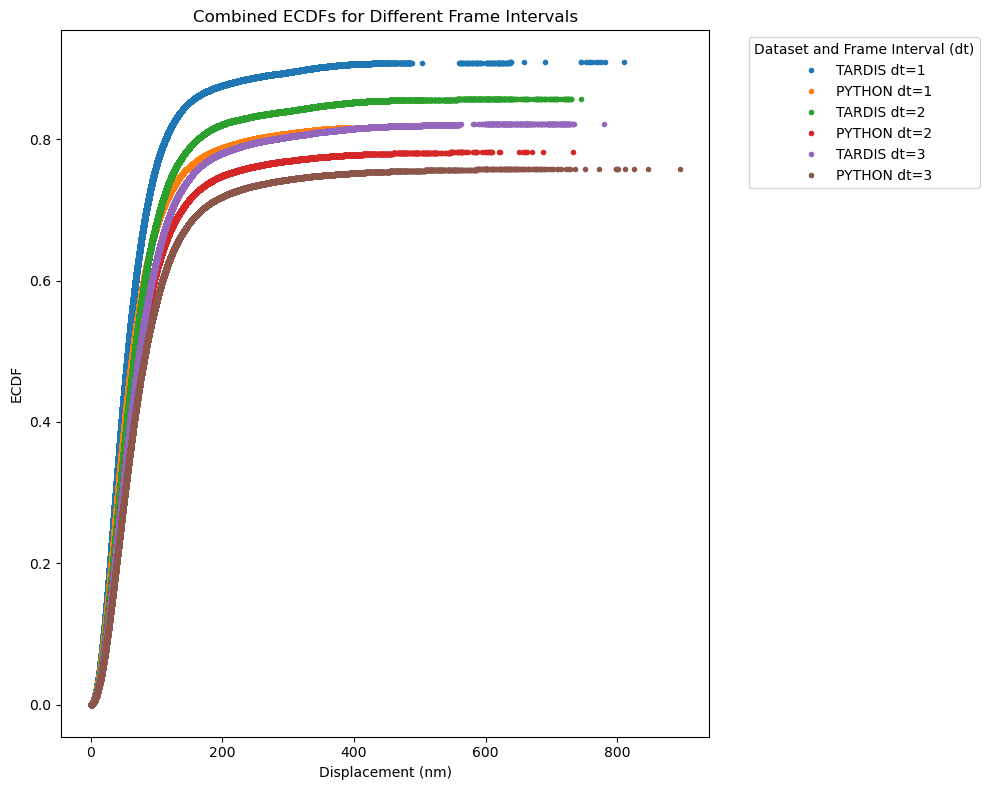

In [27]:
compare_ecdf(JDs_TARDIS,JDs_python,selected_max_fs,False)